# 09d — Introduzione al Function Calling e MCP

**Corso**: Programmazione di Applicazioni Intelligenti  
**Lezione 09** — Dal Client OpenAI al Function Calling e MCP  
**Blocco 3** — Teoria (1h)

In questo notebook vedremo come dare **superpoteri** all'LLM:
- Perché il modello ha bisogno di funzioni esterne
- Il meccanismo del function calling: chi fa cosa
- Definire tool con JSON Schema e implementare le funzioni
- Il loop completo: tool call → execute → result
- Da tool artigianali a MCP: il protocollo standard
- Costruire un MCP Server minimale


---
## Setup


In [3]:
!pip install -q openai

from openai import OpenAI
from google.colab import userdata
import json

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=userdata.get("GROQ_API_KEY"),
)
MODEL = "openai/gpt-oss-120b"
print(f"Client pronto! Modello: {MODEL}")


Client pronto! Modello: openai/gpt-oss-120b


In [4]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Che tempo farà domani a Vercelli?"}
    ]
)

# Estrarre la risposta
risposta = response.choices[0].message.content
print(risposta)

Mi dispiace, ma non posso fornire previsioni meteo in tempo reale.


---
## 4.1 — Perché serve il function calling

Un LLM, per quanto potente, ha **tre limiti strutturali**:

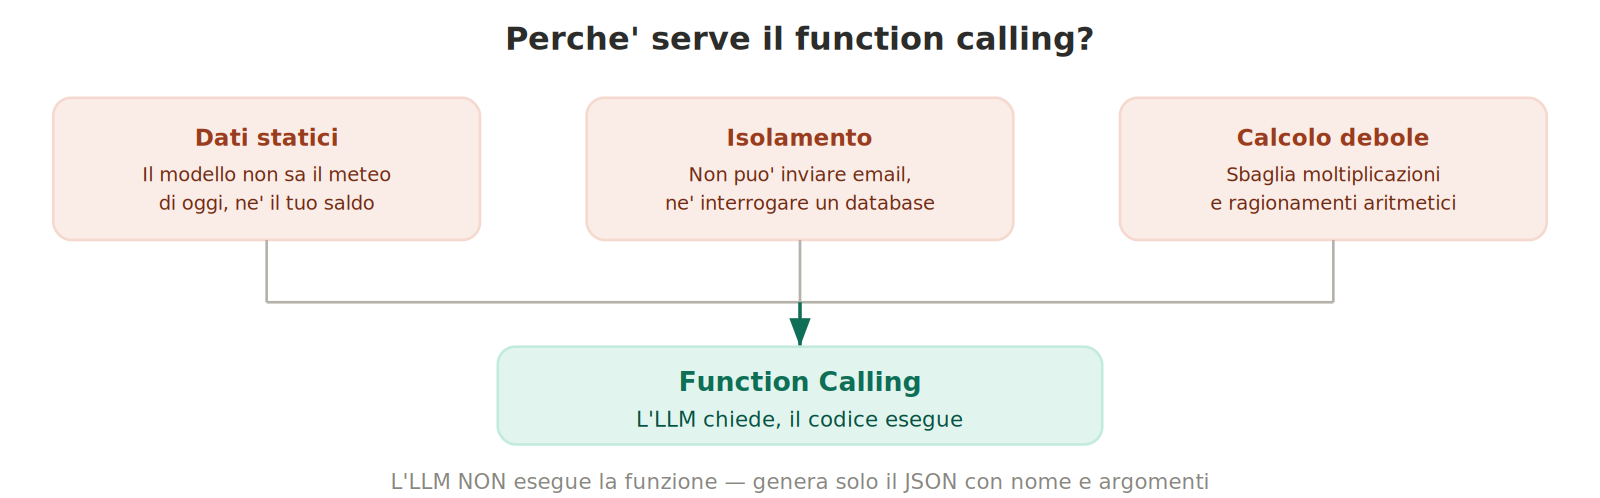

Il function calling risolve tutti e tre: il modello può **chiedere** al nostro codice di eseguire azioni (chiamare API, interrogare DB, fare calcoli) e usare i risultati per formulare la risposta.

Concetto chiave: **l'LLM non esegue la funzione**. Genera solo un JSON strutturato con il nome della funzione e gli argomenti. È il nostro codice (l'"orchestratore") che esegue la funzione e restituisce il risultato al modello.

L'analogia: l'LLM è il **cervello** che decide cosa fare. Il nostro codice sono le **mani** che agiscono.


---
## 4.2 — Il flusso del function calling: chi fa cosa

Il function calling coinvolge **4 attori** con ruoli ben distinti. Questo sequence diagram mostra l'intero flusso per una domanda come "Che tempo fa a Roma?":

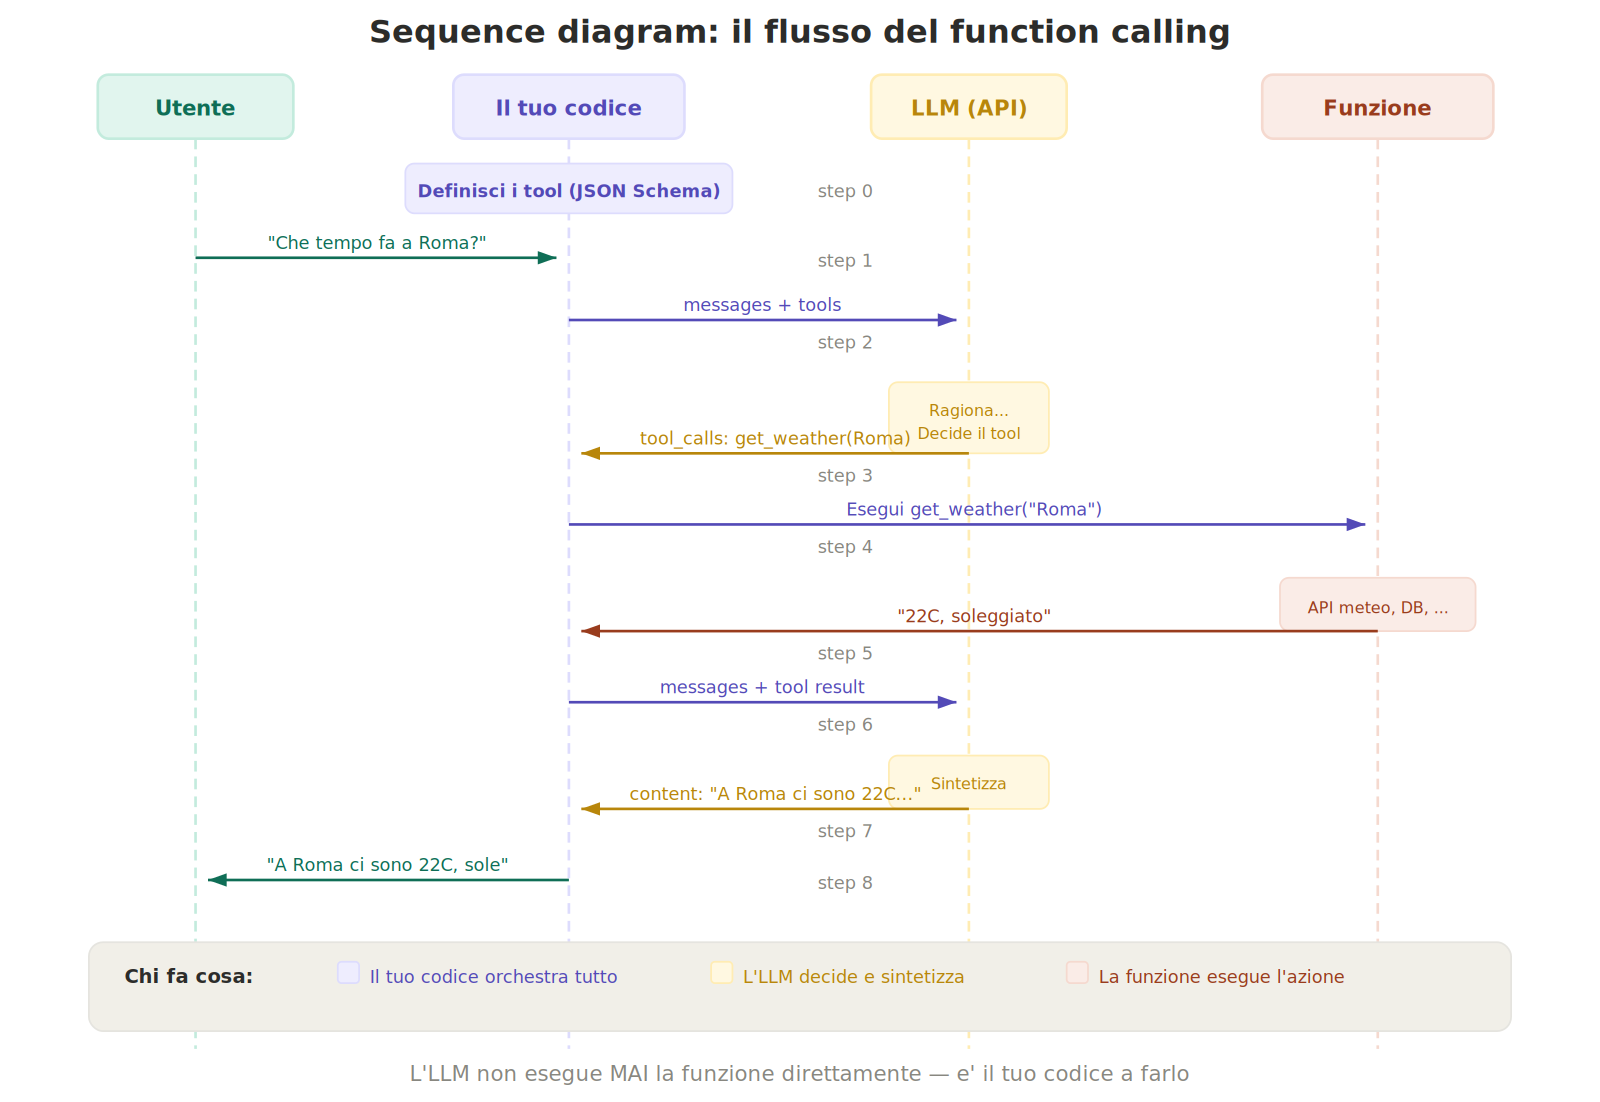

### I punti chiave:
- **Step 0**: i tool vengono definiti *dal nostro codice* prima della chiamata, usando JSON Schema
- **Step 2**: il nostro codice invia i messaggi E la lista dei tool disponibili all'LLM
- **Step 3**: l'LLM **sceglie** se e quale tool usare — non è deterministico, può decidere di non usarne nessuno
- **Step 4-5**: il nostro codice esegue la funzione — l'LLM non ha accesso diretto
- **Step 6-7**: il risultato torna all'LLM che lo usa per generare la risposta finale in linguaggio naturale


---
## 4.3 — Definire i tool: JSON Schema

Ogni tool è descritto da un oggetto JSON con tre campi principali:
- **`type`**: sempre `"function"`
- **`function.name`**: il nome della funzione
- **`function.description`**: la descrizione — **cruciale**, è ciò che il modello legge per decidere quando usare il tool
- **`function.parameters`**: i parametri, in formato JSON Schema standard

La `description` è la parte più importante: è il "prompt" che dice al modello quando e come usare il tool.


In [5]:
# Definizione di due tool
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Ottieni il meteo attuale per una città. Usa questo tool quando l'utente chiede informazioni sul tempo.",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {
                        "type": "string",
                        "description": "Il nome della città (es. 'Roma', 'Milano')"
                    },
                    "unit": {
                        "type": "string",
                        "enum": ["celsius", "fahrenheit"],
                        "description": "Unità di temperatura (default: celsius)"
                    }
                },
                "required": ["city"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "calculate",
            "description": "Esegui un calcolo matematico. Usa questo tool per qualsiasi operazione aritmetica.",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {
                        "type": "string",
                        "description": "L'espressione matematica da calcolare (es. '15 * 23 + 7')"
                    }
                },
                "required": ["expression"]
            }
        }
    }
]

print(f"Definiti {len(tools)} tool:")
for t in tools:
    print(f"  - {t['function']['name']}: {t['function']['description'][:60]}...")


Definiti 2 tool:
  - get_weather: Ottieni il meteo attuale per una città. Usa questo tool quan...
  - calculate: Esegui un calcolo matematico. Usa questo tool per qualsiasi ...


---
## 4.4 — Implementare le funzioni Python

Le definizioni JSON Schema dicono al modello *cosa* può chiedere. Ma servono anche le **funzioni Python reali** che eseguono l'azione. Creiamo un **registry** che mappa nome → funzione.


In [6]:
# Le funzioni Python reali
def get_weather(city: str, unit: str = "celsius") -> str:
    """Simula una chiamata a un'API meteo (dati fake per la demo)."""
    # In produzione qui chiameresti un'API vera (es. OpenWeatherMap)
    meteo_fake = {
        "roma": {"temp": 22, "condizione": "soleggiato"},
        "milano": {"temp": 18, "condizione": "nuvoloso"},
        "napoli": {"temp": 25, "condizione": "soleggiato"},
    }
    data = meteo_fake.get(city.lower(), {"temp": 15, "condizione": "variabile"})
    return json.dumps({
        "city": city,
        "temperature": data["temp"],
        "unit": unit,
        "condition": data["condizione"]
    })

def calculate(expression: str) -> str:
    """Calcola un'espressione matematica.
    ATTENZIONE: eval() è pericoloso in produzione! (vedi esercizio 4 del notebook 09e)
    """
    try:
        result = eval(expression)
        return json.dumps({"expression": expression, "result": result})
    except Exception as e:
        return json.dumps({"expression": expression, "error": str(e)})

# Registry: mappa nome_tool → funzione Python
tool_registry = {
    "get_weather": get_weather,
    "calculate": calculate,
}

# Test rapido
print(get_weather("Roma"))
print(calculate("15 * 23 + 7"))


{"city": "Roma", "temperature": 22, "unit": "celsius", "condition": "soleggiato"}
{"expression": "15 * 23 + 7", "result": 352}


> **Nota per il docente**: sottolineare che `eval()` è **pericoloso** in produzione — un utente malevolo potrebbe iniettare codice arbitrario. Nell'esercitazione (Notebook 09e, Esercizio 4) gli studenti dovranno implementare una versione sicura. Per questa demo usiamo `eval()` per semplicità.


---
## 4.5 — Il loop completo: tool call → execute → result

Ora mettiamo tutto insieme. Il flusso nel codice segue esattamente il sequence diagram che abbiamo visto:

1. Chiamata API con `tools=tools`
2. Controllare se `message.tool_calls` è presente
3. Per ogni tool call: estrarre nome e argomenti, eseguire, costruire il messaggio `role: "tool"`
4. Seconda chiamata API con il risultato → risposta finale


In [7]:
# Il loop completo del function calling

def ask_with_tools(question: str, tools: list, tool_registry: dict) -> str:
    """Gestisce una domanda con possibile function calling."""
    messages = [
        {"role": "system", "content": "Sei un assistente utile. Usa i tool disponibili quando necessario. Rispondi in italiano."},
        {"role": "user", "content": question}
    ]

    # --- Prima chiamata: il modello decide se usare un tool ---
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools,
    )

    message = response.choices[0].message

    # Se il modello NON vuole usare tool, restituisce direttamente la risposta
    if not message.tool_calls:
        return f"[Nessun tool usato]\n{message.content}"

    # --- Il modello vuole usare uno o più tool ---
    # Aggiungiamo il messaggio dell'assistente (con le tool_calls) alla cronologia
    messages.append(message)

    print(f"  Il modello ha richiesto {len(message.tool_calls)} tool call:")

    for tool_call in message.tool_calls:
        fn_name = tool_call.function.name
        fn_args = json.loads(tool_call.function.arguments)
        print(f"    → {fn_name}({fn_args})")

        # Eseguiamo la funzione dal registry
        fn = tool_registry[fn_name]
        result = fn(**fn_args)

        # Aggiungiamo il risultato come messaggio con role "tool"
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,  # collega il risultato alla tool_call
            "name": fn_name,
            "content": result,
        })

    # --- Seconda chiamata: il modello sintetizza la risposta finale ---
    final_response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
    )

    return final_response.choices[0].message.content


In [8]:
# Test 1: domanda che richiede il tool meteo
print("=== Domanda con tool meteo ===")
risposta = ask_with_tools("Che tempo fa a Roma?", tools, tool_registry)
print(f"Risposta: {risposta}")


=== Domanda con tool meteo ===
  Il modello ha richiesto 1 tool call:
    → get_weather({'city': 'Roma', 'unit': 'celsius'})
Risposta: A Roma attualmente fa **22 °C** e il cielo è **soleggiato**. Buona giornata!


In [9]:
# Test 2: domanda che richiede il tool calcolatrice
print("=== Domanda con tool calcolatrice ===")
risposta = ask_with_tools("Quanto fa 847 * 23 + 156?", tools, tool_registry)
print(f"Risposta: {risposta}")


=== Domanda con tool calcolatrice ===
  Il modello ha richiesto 1 tool call:
    → calculate({'expression': '847 * 23 + 156'})
Risposta: 847 × 23 + 156 = **19 637**.


In [10]:
# Test 3: domanda che NON richiede tool
print("=== Domanda senza tool ===")
risposta = ask_with_tools("Chi ha scritto la Divina Commedia?", tools, tool_registry)
print(f"Risposta: {risposta}")


=== Domanda senza tool ===
Risposta: [Nessun tool usato]
La *Divina Commedia* è stata scritta da **Dante Alighieri**, poeta fiorentino vissuto tra il 1265 e il 1321.


> **Nota per il docente**: far notare il terzo test — il modello **sceglie** di non usare nessun tool perché la domanda non lo richiede. Questa è la differenza rispetto a una pipeline deterministica: il modello ha agency nella decisione. Questo è anche il punto debole: a volte il modello *non* chiama il tool quando dovrebbe, o lo chiama quando non serve. La qualità delle `description` dei tool è fondamentale.
>
> **Parallel tool calls**: il modello può richiedere più tool nella stessa risposta (es. "Che tempo fa a Roma e quanto fa 2+2?"). Il nostro loop già li gestisce con il `for tool_call in message.tool_calls`.


---
## 4.6 — Da function calling artigianale a MCP

Il function calling che abbiamo visto funziona, ma ha un problema: **i tool sono hardcoded** nel nostro codice. Se vogliamo aggiungere un tool, dobbiamo modificare il codice, ridefinire lo schema JSON, rifare il deploy.

**Analogia**: prima dell'USB, ogni periferica aveva il suo connettore proprietario. Stampante? Porta parallela. Mouse? PS/2. Modem? Seriale. Ogni volta un cavo diverso, un driver diverso.

**MCP (Model Context Protocol)** è la **"porta USB" degli agenti AI**: un protocollo standard che permette a qualsiasi applicazione AI di connettersi a qualsiasi server di tool, senza integrazioni custom.


---
## 4.7 — MCP: architettura Host / Client / Server

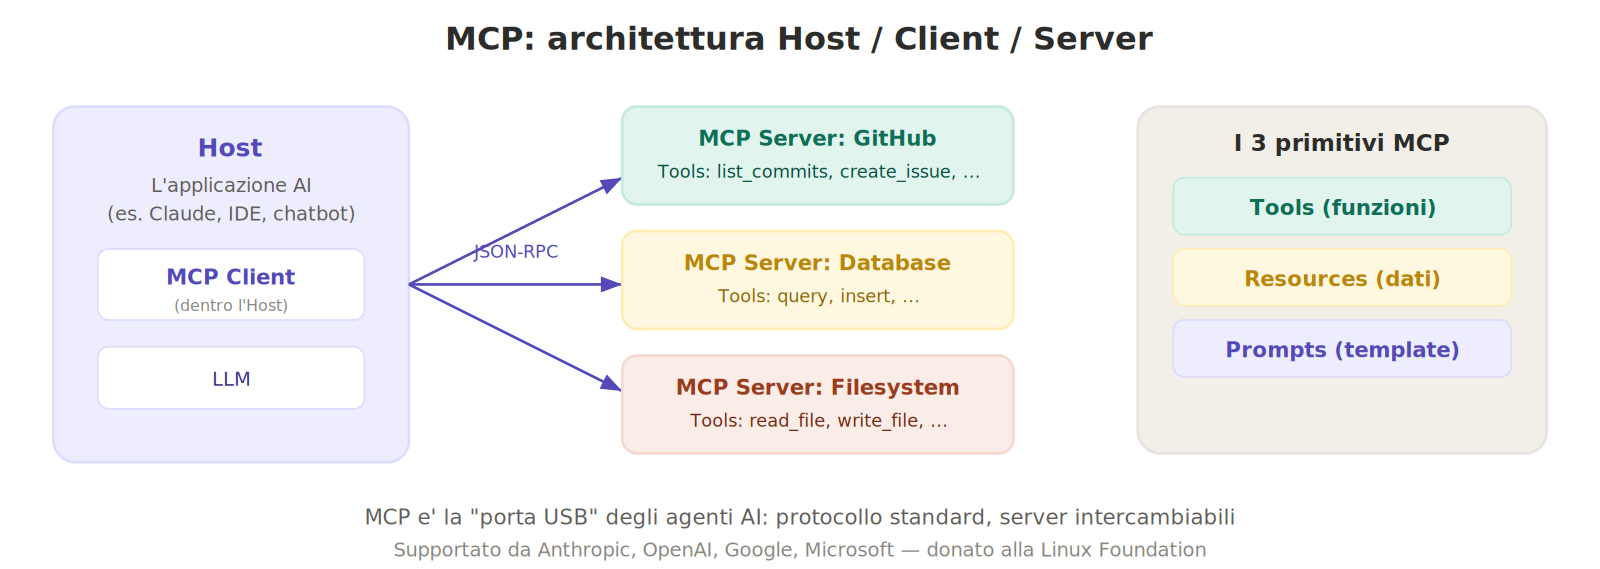

### I tre componenti:
- **Host**: l'applicazione AI (Claude Desktop, un IDE, il tuo chatbot) che vuole usare tool esterni
- **MCP Client**: vive dentro l'Host, gestisce la comunicazione con i Server MCP
- **MCP Server**: espone tool, risorse e prompt template via un protocollo standard (JSON-RPC 2.0)

### I tre primitivi di un MCP Server:
- **Tools**: funzioni che l'LLM può invocare (come il function calling, ma standardizzato)
- **Resources**: dati che l'LLM può leggere (file, record DB, documenti)
- **Prompts**: template di prompt riutilizzabili

### Ecosistema
MCP è supportato da Anthropic, OpenAI, Google, Microsoft, AWS. L'SDK ha oltre 97M di download al mese. Il protocollo è stato donato alla Linux Foundation (AAIF) per garantirne la neutralità.


---
## 4.8 — Costruiamo un MCP Server minimale

Con la libreria `mcp` (FastMCP), creare un server è molto più semplice che definire tool a mano con JSON Schema. Un decoratore `@mcp.tool()` fa tutto il lavoro.


In [ ]:
# Installazione
!pip install -q "mcp[cli]"

from mcp.server.fastmcp import FastMCP

# Crea il server (non lo lanciamo con .run(), lo usiamo come oggetto)
mcp = FastMCP("Meteo Server")

@mcp.tool()
def get_weather(city: str, unit: str = "celsius") -> str:
    """Ottieni il meteo attuale per una citta'."""
    meteo = {
        "roma": {"temp": 22, "condizione": "soleggiato"},
        "milano": {"temp": 18, "condizione": "nuvoloso"},
    }
    data = meteo.get(city.lower(), {"temp": 15, "condizione": "variabile"})
    return f"{city}: {data['temp']}°C, {data['condizione']}"

# --- Ispezione: cosa "vede" un client MCP ---

# 1. Lista dei tool registrati
import asyncio

async def esplora_server():
    tools = await mcp.list_tools()
    for t in tools:
        print(f"Tool: {t.name}")
        print(f"  Descrizione: {t.description}")
        print(f"  Schema input: {t.inputSchema}")
        print()

    # 2. Invocazione diretta di un tool
    risultato = await mcp.call_tool("get_weather", {"city": "Roma"})

    # Il risultato è una lista di content blocks (come in MCP)
    content_blocks = risultato[0] if isinstance(risultato, tuple) else risultato
    for block in content_blocks:
        print(f"Tipo: {block.type}")
        print(f"Testo: {block.text}")

await esplora_server()

Tool: get_weather
  Descrizione: Ottieni il meteo attuale per una citta'.
  Schema input: {'properties': {'city': {'title': 'City', 'type': 'string'}, 'unit': {'default': 'celsius', 'title': 'Unit', 'type': 'string'}}, 'required': ['city'], 'title': 'get_weatherArguments', 'type': 'object'}

Tipo: text
Testo: Roma: 22°C, soleggiato


### Confronto: tool manuale vs MCP

| | **Function calling manuale** | **MCP Server** |
|---|---|---|
| **Definizione tool** | JSON Schema scritto a mano (~20 righe) | `@mcp.tool()` su una funzione Python (~2 righe) |
| **Discovery** | Hardcoded nel codice | Il client chiede al server quali tool ha |
| **Riuso** | Copia-incolla tra progetti | Un server serve N applicazioni |
| **Standard** | Nessuno (formato OpenAI de facto) | JSON-RPC 2.0, specifica aperta |
| **Ecosistema** | Devi scrivere tutto | Migliaia di server MCP già disponibili |


---
## 4.9 — MCP in azione: esempio d'uso

Immagina di chiedere al tuo assistente AI: *"Riassumi gli ultimi 5 commit del repo X"*.

Il flusso con MCP:
1. **Host** (es. Claude Desktop) chiede al **MCP Server GitHub**: "Quali tool hai?"
2. Il Server risponde: `list_commits`, `create_issue`, `get_file`, ...
3. L'**LLM** sceglie `list_commits(repo="X", n=5)`
4. L'Host esegue la tool call verso il Server, che chiama l'API GitHub
5. Il risultato (i 5 commit) torna all'LLM
6. L'LLM sintetizza il riassunto in linguaggio naturale

Il bello è che l'Host non ha bisogno di sapere *come* funziona l'API GitHub. Il Server MCP è un intermediario standardizzato.

> **Nota per il docente**: se il tempo lo consente, mostrare il [registry di MCP Server](https://github.com/modelcontextprotocol/servers) — ci sono server per GitHub, Slack, PostgreSQL, filesystem, Google Drive, e molti altri. Questo rende concreto il concetto di "ecosistema".


---
## 4.10 — Riepilogo e anticipazione

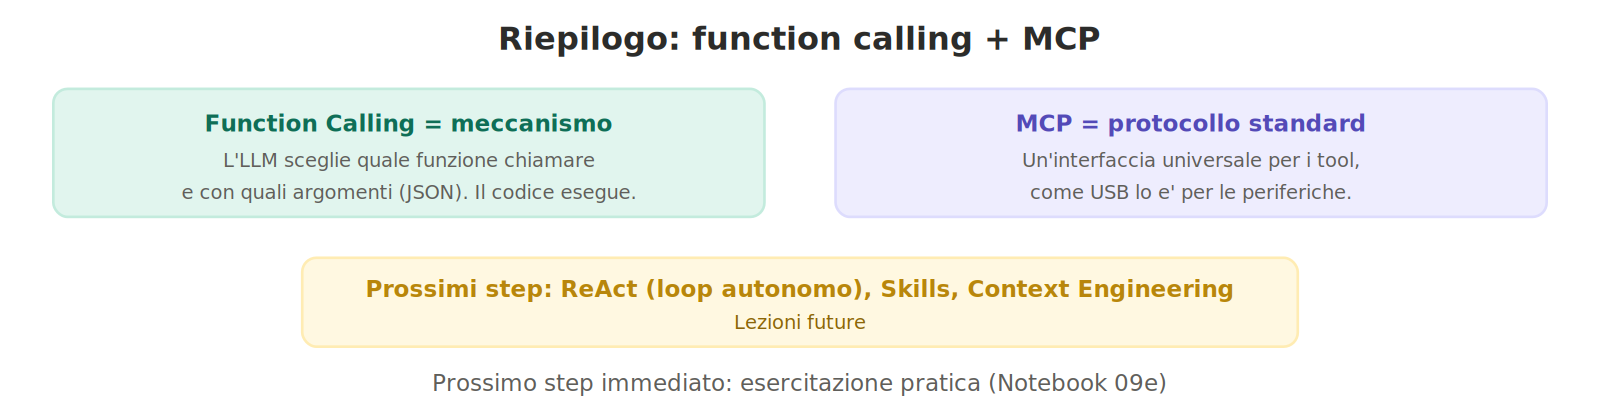